# WMaxTwin for the Marron-Wand Claw Density

This notebook reproduces and explains **Numerical Experiment I: WMaxTwin for the Claw Density** from the manuscript *Multiscale MaxTwin: Data Splitting as Multiscale Feature Geometry*.

The goal is to isolate the effect of the **split geometry**.  The density estimator, kernel bandwidth, AMSE loss, random sample, and evaluation grid are held fixed within each Monte Carlo replication.  Only the half-sample split changes.

The comparison is:

1. **Random split**: balanced half-sample split with no feature geometry.
2. **MaxTwin$^+$**: strengthened nonwavelet MaxTwin baseline using local rank structure, rank-bin indicators, and smooth rank bumps.
3. **WMaxTwin$^+$**: same local-pair design idea, but the pair orientations are chosen in an augmented feature space that includes Haar scale-location atoms evaluated at the sample locations.

The paper's central claim for this example is deliberately modest but important: **WMaxTwin improves on a competitive nonwavelet MaxTwin baseline because the Haar features detect narrow local components that rank-local geometry does not fully represent.**

## 1. Mathematical setup

The target is the Marron-Wand claw density

$$
f(x)
=
0.5\,\phi(x;0,1)
+
0.1\sum_{\ell=0}^{4}
\phi\left(x;{\ell\over 2}-1,0.1^2\right),
$$

where $\phi(\cdot;m,v)$ denotes a Gaussian density with mean $m$ and variance $v$.

The broad $N(0,1)$ component gives a smooth background.  The five narrow components create localized peaks.  This makes the example useful for split geometry: a split may look balanced globally but still allocate observations unevenly across the narrow claws.

The WMaxTwin density construction does **not** take a DWT of the unordered sample vector.  Instead, Haar wavelets are used as localized test functions evaluated at the sample locations.  This is the appropriate wavelet geometry for scalar density samples.

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.stats import norm
from IPython.display import display

pd.set_option("display.precision", 5)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

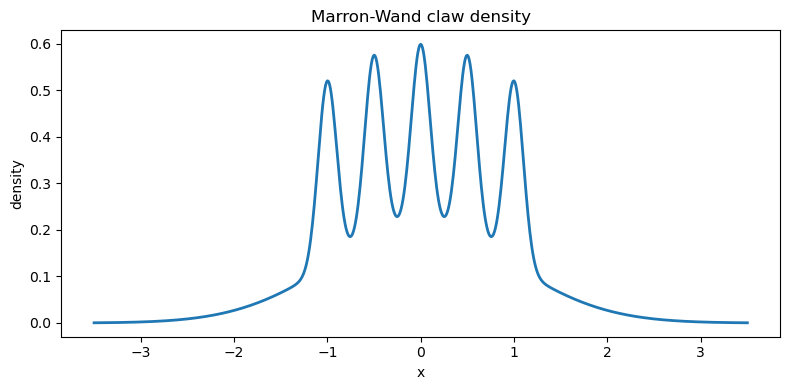

In [2]:
def claw_pdf(x: np.ndarray) -> np.ndarray:
    """Marron-Wand claw density."""
    x = np.asarray(x)
    y = 0.5 * norm.pdf(x, loc=0.0, scale=1.0)
    for ell in range(5):
        y += 0.1 * norm.pdf(x, loc=ell / 2.0 - 1.0, scale=0.1)
    return y


def sample_claw(n: int, rng: np.random.Generator) -> np.ndarray:
    """Draw n observations from the claw density."""
    comp = rng.choice(6, size=n, p=[0.5] + [0.1] * 5)
    means = np.array([0.0, -1.0, -0.5, 0.0, 0.5, 1.0])
    sds = np.array([1.0, 0.1, 0.1, 0.1, 0.1, 0.1])
    return rng.normal(loc=means[comp], scale=sds[comp])


grid = np.linspace(-3.5, 3.5, 701)
true_pdf = claw_pdf(grid)

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.plot(grid, true_pdf, linewidth=2.0)
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.set_title("Marron-Wand claw density")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_00_claw_density.png", dpi=200)
plt.show()

## 2. Feature geometry

For a sample $X_1,\ldots,X_n$, define the standardized coordinate and rank coordinate

$$
Z_i={X_i-\bar X\over s_X},
\qquad
u_i={\operatorname{rank}(X_i)\over n+1}.
$$

The strengthened nonwavelet baseline uses

$$
F_M(X_i)
=
\left(
Z_i,
Z_i^2,
Z_i^3,
Z_i^4,
B_1(X_i),\ldots,B_R(X_i),
G_1(X_i),\ldots,G_M(X_i)
\right),
$$

where $B_r$ are rank-bin indicators and $G_m$ are smooth rank bumps.  This is intentionally stronger than a simple moment-matching baseline.

The WMaxTwin feature vector augments $F_M$ with Haar detail atoms and finest scaling indicators evaluated on the physical interval $[-3,3]$:

$$
F_W(X_i)
=
\left(F_M(X_i),\{\psi_{j,k}(u_i^x)\},\{\phi_{J,k}(u_i^x)\}\right),
\qquad
u_i^x={X_i-a\over b-a},\quad [a,b]=[-3,3].
$$

Both the MaxTwin block and the wavelet block are standardized and given equal group weight.  Thus the comparison is not biased by feature dimension.

In [3]:
def standardize_columns(F: np.ndarray) -> np.ndarray:
    """Center columns, remove constants, and scale to empirical standard deviation one."""
    F = np.asarray(F, dtype=float)
    F = F - F.mean(axis=0, keepdims=True)
    sd = F.std(axis=0, ddof=1)
    keep = sd > 1.0e-12
    return F[:, keep] / sd[keep]


def rank_coordinate(x: np.ndarray) -> np.ndarray:
    """Empirical rank coordinate in (0,1)."""
    n = len(x)
    ranks = np.empty(n, dtype=int)
    ranks[np.argsort(x)] = np.arange(1, n + 1)
    return ranks / (n + 1.0)


def maxtwin_plus_features(x: np.ndarray, R: int = 10, M: int | None = None) -> np.ndarray:
    """Nonwavelet MaxTwin+ features: moments, rank bins, and smooth rank bumps."""
    if M is None:
        M = R
    z = (x - x.mean()) / (x.std(ddof=1) + 1.0e-12)
    u = rank_coordinate(x)

    cols = [z, z**2, z**3, z**4]

    for r in range(R):
        lo, hi = r / R, (r + 1) / R
        cols.append(((u > lo) & (u <= hi)).astype(float))

    tau = 1.2 / (M + 1)
    for m in range(1, M + 1):
        c = m / (M + 1)
        cols.append(np.exp(-0.5 * ((u - c) / tau) ** 2))

    return standardize_columns(np.column_stack(cols))


def haar_wavelet_features(
    x: np.ndarray,
    J: int = 5,
    J0: int | None = None,
    a: float = -3.0,
    b: float = 3.0,
) -> np.ndarray:
    """Pure-Python Haar detail and finest scaling features on the physical x scale."""
    if J0 is None:
        J0 = max(1, J - 3)

    u = np.clip((x - a) / (b - a), 0.0, 1.0 - 1.0e-12)
    cols = []

    for j in range(J0, J + 1):
        m = 2**j
        bins = np.floor(u * m).astype(int)
        loc = u * m - bins
        scale = 2 ** (j / 2)
        for k in range(m):
            v = np.zeros_like(u)
            idx = bins == k
            v[idx] = np.where(loc[idx] < 0.5, 1.0, -1.0) * scale
            cols.append(v)

    # Finest scaling cells make the split sensitive to local mass allocations.
    m = 2**J
    bins = np.floor(u * m).astype(int)
    scale = 2 ** (J / 2)
    for k in range(m):
        cols.append((bins == k).astype(float) * scale)

    return standardize_columns(np.column_stack(cols))


def wmaxtwin_plus_features(x: np.ndarray, R: int = 10, J: int = 5) -> np.ndarray:
    """Equal-group-weighted MaxTwin+ and Haar wavelet features."""
    Fm = maxtwin_plus_features(x, R=R, M=R)
    Fw = haar_wavelet_features(x, J=J)
    Fm = Fm / np.sqrt(Fm.shape[1])
    Fw = Fw / np.sqrt(Fw.shape[1])
    return np.column_stack([Fm, Fw])

## 3. Split construction

Each split is encoded by a vector

$$
y\in\{-1,+1\}^n.
$$

The two halves are

$$
A(y)=\{i:y_i=+1\},
\qquad
B(y)=\{i:y_i=-1\}.
$$

The strengthened MaxTwin$^+$ split first balances coarse rank blocks and then performs improving within-block swaps to reduce the feature imbalance

$$
\|F_M' y\|_2^2.
$$

The WMaxTwin$^+$ split first separates adjacent order-statistic pairs, so that each half receives one point from each local pair.  It then chooses pair orientations to reduce

$$
\|F_W' y\|_2^2.
$$

This is the key mechanism: WMaxTwin$^+$ changes the **orientation of local pairs** using Haar scale-location features.  It is not merely relabeling MaxTwin$^+$.

In [4]:
def random_split(n: int, rng: np.random.Generator) -> np.ndarray:
    """Balanced random split encoded by +/-1."""
    y = np.r_[np.ones(n // 2, dtype=int), -np.ones(n - n // 2, dtype=int)]
    rng.shuffle(y)
    return y


def feature_objective(F: np.ndarray, y: np.ndarray) -> float:
    """Scaled feature imbalance ||F'y||^2 / p."""
    s = F.T @ y
    return float(s @ s) / F.shape[1]


def maxtwin_plus_split(
    x: np.ndarray,
    rng: np.random.Generator,
    R: int = 10,
    n_flips: int = 600,
) -> np.ndarray:
    """
    Improved nonwavelet MaxTwin+ split.

    The split first balances coarse empirical rank blocks. Then it performs
    improving within-block swaps to reduce the MaxTwin+ feature imbalance while
    preserving the exact rank-block balance.
    """
    n = len(x)
    idx = np.argsort(x)
    blocks = np.array_split(idx, R)
    block_id = np.empty(n, dtype=int)
    y = np.zeros(n, dtype=int)
    leftovers = []

    for bi, bidx in enumerate(blocks):
        block_id[bidx] = bi
        bcopy = bidx.copy()
        rng.shuffle(bcopy)
        m = len(bcopy) // 2
        y[bcopy[:m]] = 1
        y[bcopy[m : 2 * m]] = -1
        if len(bcopy) % 2 == 1:
            leftovers.append(int(bcopy[-1]))

    if leftovers:
        rng.shuffle(leftovers)
        n_plus = int((y == 1).sum())
        target_plus = n // 2
        for ii in leftovers:
            if n_plus < target_plus:
                y[ii] = 1
                n_plus += 1
            else:
                y[ii] = -1

    F = maxtwin_plus_features(x, R=R, M=R)
    s = F.T @ y
    cur = float(s @ s) / F.shape[1]

    # Swaps only within the same rank block, so rank-block balance is preserved.
    for _ in range(n_flips):
        bi = int(rng.integers(R))
        inds = np.where(block_id == bi)[0]
        pp = inds[y[inds] == 1]
        mm = inds[y[inds] == -1]
        if len(pp) == 0 or len(mm) == 0:
            continue
        ip = int(rng.choice(pp))
        im = int(rng.choice(mm))
        ds = -2.0 * F[ip] + 2.0 * F[im]
        ns = s + ds
        new = float(ns @ ns) / F.shape[1]
        if new < cur:
            y[ip] = -1
            y[im] = 1
            s = ns
            cur = new

    return y


def orient_adjacent_pairs(
    pairs: np.ndarray,
    F: np.ndarray,
    rng: np.random.Generator,
    restarts: int = 10,
    sweeps: int = 5,
) -> np.ndarray:
    """Choose pair orientations by minimizing feature imbalance."""
    D = F[pairs[:, 0], :] - F[pairs[:, 1], :]
    m = D.shape[0]
    best_sgn = None
    best_obj = np.inf

    for _ in range(restarts):
        sgn = rng.choice([-1, 1], size=m)
        vec = D.T @ sgn
        cur = float(vec @ vec) / F.shape[1]

        for _sweep in range(sweeps):
            improved = False
            for q in rng.permutation(m):
                new_vec = vec - 2.0 * sgn[q] * D[q]
                new_obj = float(new_vec @ new_vec) / F.shape[1]
                if new_obj < cur:
                    vec = new_vec
                    cur = new_obj
                    sgn[q] *= -1
                    improved = True
            if not improved:
                break

        if cur < best_obj:
            best_obj = cur
            best_sgn = sgn.copy()

    return best_sgn


def wmaxtwin_plus_split(
    x: np.ndarray,
    rng: np.random.Generator,
    R: int = 10,
    J: int = 5,
    restarts: int = 10,
) -> np.ndarray:
    """
    Wavelet-enhanced WMaxTwin+ split.

    Adjacent order-statistic pairs enforce very local balance. Pair orientations
    are then chosen by minimizing imbalance in MaxTwin+ features augmented with
    Haar wavelet atoms.
    """
    n = len(x)
    idx = np.argsort(x)
    pairs = idx.reshape(n // 2, 2)
    F = wmaxtwin_plus_features(x, R=R, J=J)
    sgn = orient_adjacent_pairs(pairs, F, rng, restarts=restarts, sweeps=5)

    y = np.zeros(n, dtype=int)
    for q, (a, b) in enumerate(pairs):
        y[a] = int(sgn[q])
        y[b] = -int(sgn[q])
    return y

## 4. Density estimation and AMSE

For a fixed split $y$, the two half-sample KDEs are

$$
\widehat f_{A,h}(x)
=
{1\over |A|h}
\sum_{i\in A}
K\left({x-X_i\over h}\right),
\qquad
\widehat f_{B,h}(x)
=
{1\over |B|h}
\sum_{i\in B}
K\left({x-X_i\over h}\right).
$$

The reported AMSE is

$$
{\rm AMSE}(y)
=
{1\over 2}\int\{\widehat f_{A,h}(x)-f(x)\}^2\,dx
+
{1\over 2}\int\{\widehat f_{B,h}(x)-f(x)\}^2\,dx.
$$

The bandwidth is fixed at $h=0.11$ for all methods.  Therefore, within a replication, AMSE differences are attributable to the split geometry.

In [5]:
def kde_eval(x: np.ndarray, grid: np.ndarray, h: float) -> np.ndarray:
    """Gaussian KDE evaluated on a grid."""
    return norm.pdf((grid[:, None] - x[None, :]) / h).mean(axis=1) / h


def split_amse(x: np.ndarray, y: np.ndarray, grid: np.ndarray, true_pdf: np.ndarray, h: float) -> float:
    """Average ISE of the two half-sample KDEs."""
    f_plus = kde_eval(x[y == 1], grid, h)
    f_minus = kde_eval(x[y == -1], grid, h)
    ise_plus = trapezoid((f_plus - true_pdf) ** 2, grid)
    ise_minus = trapezoid((f_minus - true_pdf) ** 2, grid)
    return 0.5 * (ise_plus + ise_minus)

## 5. Monte Carlo experiment

The manuscript reports four settings:

| $n$ | $J$ | $R$ |
|---:|---:|---:|
| 60 | 5 | 8 |
| 80 | 5 | 10 |
| 80 | 6 | 10 |
| 120 | 5 | 12 |

The default below uses 150 Monte Carlo replications, matching the paper.  For a quick check, set `REPS = 20`; for the paper run, keep `REPS = 150`.

In [6]:
def run_simulation(
    reps: int = 150,
    seed: int = 20260619,
    h: float = 0.11,
    output_dir: str | Path = OUTPUT_DIR,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    settings = [
        {"n": 60, "J": 5, "R": 8},
        {"n": 80, "J": 5, "R": 10},
        {"n": 80, "J": 6, "R": 10},
        {"n": 120, "J": 5, "R": 12},
    ]

    rng = np.random.default_rng(seed)
    grid = np.linspace(-3.5, 3.5, 701)
    true_pdf = claw_pdf(grid)

    rows = []
    example = {}

    for st in settings:
        n, J, R = st["n"], st["J"], st["R"]
        for rep in range(reps):
            x = sample_claw(n, rng)
            y_random = random_split(n, rng)
            y_max = maxtwin_plus_split(x, rng, R=R, n_flips=700)
            y_wmax = wmaxtwin_plus_split(x, rng, R=R, J=J, restarts=10)

            ar = split_amse(x, y_random, grid, true_pdf, h)
            am = split_amse(x, y_max, grid, true_pdf, h)
            aw = split_amse(x, y_wmax, grid, true_pdf, h)

            rows.append(
                {
                    "n": n,
                    "J": J,
                    "R": R,
                    "rep": rep + 1,
                    "AMSE_Random": ar,
                    "AMSE_MaxTwin_plus": am,
                    "AMSE_WMaxTwin_plus": aw,
                    "diff_Random_minus_MaxTwin_plus": ar - am,
                    "diff_MaxTwin_plus_minus_WMaxTwin_plus": am - aw,
                    "abs_signed_overlap": abs(float(y_max @ y_wmax)) / n,
                }
            )

            if not example and n == 80 and J == 6 and rep == 0:
                example = {
                    "x": x.copy(),
                    "y_random": y_random.copy(),
                    "y_max": y_max.copy(),
                    "y_wmax": y_wmax.copy(),
                    "grid": grid.copy(),
                    "true_pdf": true_pdf.copy(),
                    "h": h,
                }

    reps_df = pd.DataFrame(rows)

    summary_rows = []
    for (n, J, R), gdf in reps_df.groupby(["n", "J", "R"], sort=False):
        mr = gdf["AMSE_Random"].mean()
        mm = gdf["AMSE_MaxTwin_plus"].mean()
        mw = gdf["AMSE_WMaxTwin_plus"].mean()
        summary_rows.append(
            {
                "n": n,
                "J": J,
                "R": R,
                "Random": mr,
                "MaxTwin_plus": mm,
                "WMaxTwin_plus": mw,
                "Gain_WMaxTwin_vs_Random_percent": 100.0 * (mr - mw) / mr,
                "Gain_WMaxTwin_vs_MaxTwin_percent": 100.0 * (mm - mw) / mm,
                "Gain_MaxTwin_vs_Random_percent": 100.0 * (mr - mm) / mr,
                "Median_abs_signed_overlap": gdf["abs_signed_overlap"].median(),
                "Frac_MaxTwin_better_than_Random": (gdf["AMSE_MaxTwin_plus"] < gdf["AMSE_Random"]).mean(),
                "Frac_WMaxTwin_better_than_MaxTwin": (gdf["AMSE_WMaxTwin_plus"] < gdf["AMSE_MaxTwin_plus"]).mean(),
            }
        )
    summary_df = pd.DataFrame(summary_rows)

    reps_df.to_csv(output_dir / "wmaxtwin_plus_replicates.csv", index=False)
    summary_df.to_csv(output_dir / "wmaxtwin_plus_amse_table.csv", index=False)

    return summary_df, reps_df, example

In [7]:
REPS = 150
SEED = 20260619
H = 0.11

summary_df, reps_df, example = run_simulation(reps=REPS, seed=SEED, h=H, output_dir=OUTPUT_DIR)
summary_df

,n,J,R,Random,MaxTwin_plus,WMaxTwin_plus,Gain_WMaxTwin_vs_Random_percent,Gain_WMaxTwin_vs_MaxTwin_percent,Gain_MaxTwin_vs_Random_percent,Median_abs_signed_overlap,Frac_MaxTwin_better_than_Random,Frac_WMaxTwin_better_than_MaxTwin
0,60,5,8,0.08797,0.06145,0.05451,38.03249,11.28520,30.14975,0.13333,0.96667,0.98667
1,80,5,10,0.06929,0.04909,0.04385,36.72059,10.68314,29.15177,0.10000,1.00000,0.99333
2,80,6,10,0.07346,0.05313,0.04857,33.87557,8.58405,27.66642,0.10000,0.98667,0.97333
3,120,5,12,0.05147,0.03646,0.03365,34.61433,7.70728,29.15403,0.10000,0.99333,1.00000


### Interpretation of the AMSE table

Smaller AMSE is better.  
The important comparison is not WMaxTwin$^+$ against a weak random baseline.  It is WMaxTwin$^+$ against MaxTwin$^+$, which already contains local rank information.  The extra improvement is due to the Haar scale-location block.

In [8]:
# A compact display table in the format used in the paper.
paper_table = summary_df[[
    "n", "J", "R", "Random", "MaxTwin_plus", "WMaxTwin_plus",
    "Gain_WMaxTwin_vs_Random_percent", "Gain_WMaxTwin_vs_MaxTwin_percent",
]].copy()

paper_table = paper_table.rename(columns={
    "MaxTwin_plus": "MaxTwin",
    "WMaxTwin_plus": "WMaxTwin",
    "Gain_WMaxTwin_vs_Random_percent": "Gain W/R (%)",
    "Gain_WMaxTwin_vs_MaxTwin_percent": "Gain W/M (%)",
})

display(paper_table.round({
    "Random": 5,
    "MaxTwin": 5,
    "WMaxTwin": 5,
    "Gain W/R (%)": 2,
    "Gain W/M (%)": 2,
}))

,n,J,R,Random,MaxTwin,WMaxTwin,Gain W/R (%),Gain W/M (%)
0,60,5,8,0.08797,0.06145,0.05451,38.03,11.29
1,80,5,10,0.06929,0.04909,0.04385,36.72,10.68
2,80,6,10,0.07346,0.05313,0.04857,33.88,8.58
3,120,5,12,0.05147,0.03646,0.03365,34.61,7.71


## 6. Figures

The next four figures are produced directly by the notebook and saved to the `outputs/` directory.

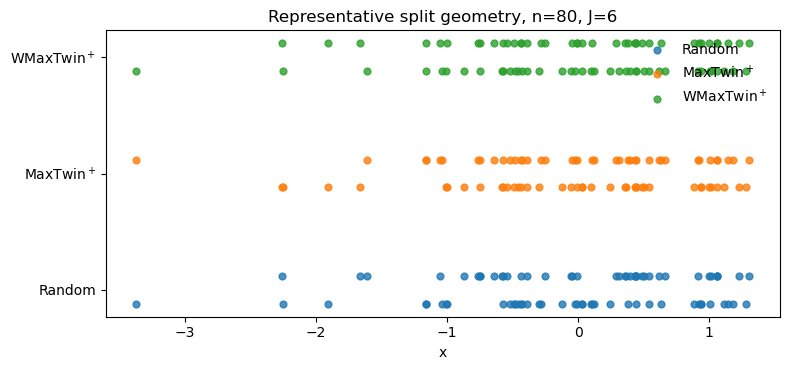

In [9]:
# Figure 1: Representative split geometry.
x = example["x"]
methods = [
    ("Random", example["y_random"], 0),
    ("MaxTwin$^+$", example["y_max"], 1),
    ("WMaxTwin$^+$", example["y_wmax"], 2),
]

fig, ax = plt.subplots(figsize=(8.0, 3.8))
for label, y, base in methods:
    yy = base + 0.12 * y
    ax.scatter(x, yy, s=24, alpha=0.8, label=label)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Random", "MaxTwin$^+$", "WMaxTwin$^+$"])
ax.set_xlabel("x")
ax.set_title("Representative split geometry, n=80, J=6")
ax.legend(loc="upper right", frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_01_wmaxtwin_plus_split_geometry.png", dpi=200)
plt.show()

**Figure 1.** The WMaxTwin$^+$ split keeps the local-pair structure but changes the pair orientations using Haar scale-location information.  This is the geometric mechanism behind the improvement.

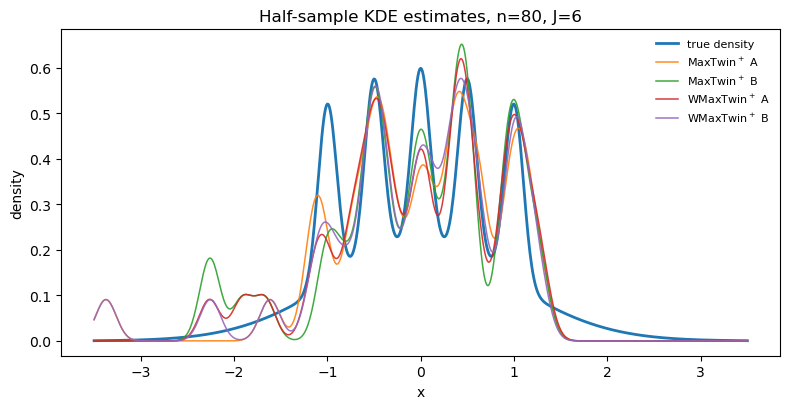

In [10]:
# Figure 2: Half-sample KDE estimates for the representative sample.
grid = example["grid"]
true_pdf = example["true_pdf"]
h = example["h"]

fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.plot(grid, true_pdf, linewidth=2.0, label="true density")
for label, y in [
    ("MaxTwin$^+$ A", example["y_max"]),
    ("MaxTwin$^+$ B", -example["y_max"]),
    ("WMaxTwin$^+$ A", example["y_wmax"]),
    ("WMaxTwin$^+$ B", -example["y_wmax"]),
]:
    ax.plot(grid, kde_eval(x[y == 1], grid, h), linewidth=1.1, alpha=0.9, label=label)
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.set_title("Half-sample KDE estimates, n=80, J=6")
ax.legend(loc="upper right", frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_02_wmaxtwin_plus_density_estimates.png", dpi=200)
plt.show()

**Figure 2.** The WMaxTwin$^+$ halves track the narrow claw features more stably.  The improvement is local: the Haar atoms help control how the two halves represent the narrow density components.

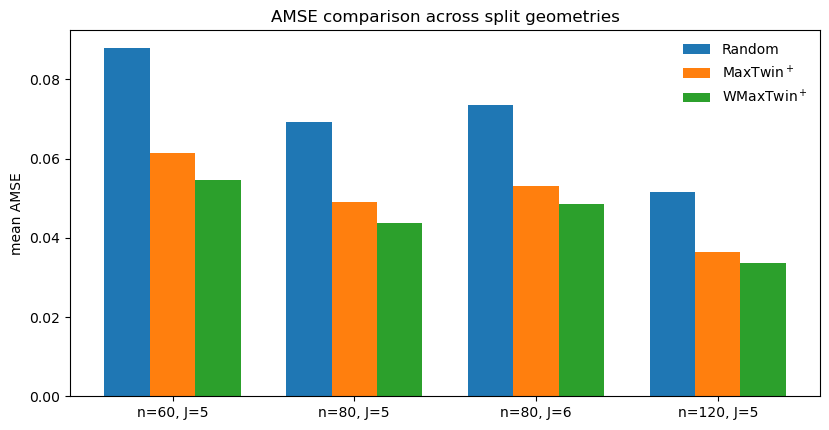

In [11]:
# Figure 3: AMSE bars.
labels = [f"n={int(r.n)}, J={int(r.J)}" for _, r in summary_df.iterrows()]
xpos = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(xpos - width, summary_df["Random"], width, label="Random")
ax.bar(xpos, summary_df["MaxTwin_plus"], width, label="MaxTwin$^+$")
ax.bar(xpos + width, summary_df["WMaxTwin_plus"], width, label="WMaxTwin$^+$")
ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_ylabel("mean AMSE")
ax.set_title("AMSE comparison across split geometries")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_03_wmaxtwin_plus_amse_bars.png", dpi=200)
plt.show()

**Figure 3.** The bar plot summarizes the mean ordering.  In each setting, WMaxTwin$^+$ has the smallest mean AMSE.

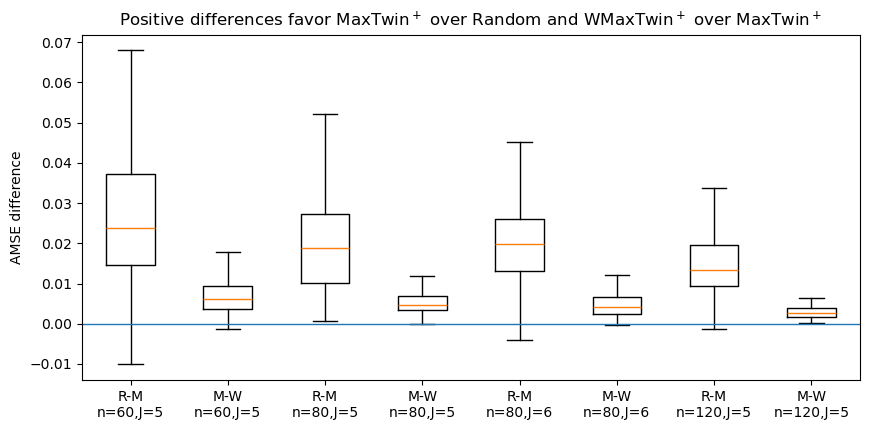

In [12]:
# Figure 4: Replication-level AMSE differences.
diff_data = []
diff_labels = []
for (n, J), gdf in reps_df.groupby(["n", "J"], sort=False):
    diff_data.append(gdf["diff_Random_minus_MaxTwin_plus"].to_numpy())
    diff_labels.append(f"R-M\nn={n},J={J}")
    diff_data.append(gdf["diff_MaxTwin_plus_minus_WMaxTwin_plus"].to_numpy())
    diff_labels.append(f"M-W\nn={n},J={J}")

fig, ax = plt.subplots(figsize=(8.8, 4.4))
try:
    ax.boxplot(diff_data, tick_labels=diff_labels, showfliers=False)
except TypeError:
    ax.boxplot(diff_data, labels=diff_labels, showfliers=False)
ax.axhline(0.0, linewidth=1.0)
ax.set_ylabel("AMSE difference")
ax.set_title("Positive differences favor MaxTwin$^+$ over Random and WMaxTwin$^+$ over MaxTwin$^+$")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_04_wmaxtwin_plus_amse_differences.png", dpi=200)
plt.show()

**Figure 4.** This is the most direct evidence for the incremental WMaxTwin$^+$ contribution.  The R-M boxes show that MaxTwin$^+$ usually improves on Random.  The M-W boxes show that the wavelet feature geometry usually gives an additional improvement beyond MaxTwin$^+$.

## 7. Replication-level diagnostics

The next table reports two useful diagnostics.

* `Frac_MaxTwin_better_than_Random`: fraction of replications in which MaxTwin$^+$ has lower AMSE than Random.
* `Frac_WMaxTwin_better_than_MaxTwin`: fraction of replications in which WMaxTwin$^+$ has lower AMSE than MaxTwin$^+$.

The second column is the key diagnostic for this example.  It checks whether the WMaxTwin improvement is a stable replication-level phenomenon, not just a difference in means.

In [13]:
diagnostic_table = summary_df[[
    "n", "J", "R",
    "Median_abs_signed_overlap",
    "Frac_MaxTwin_better_than_Random",
    "Frac_WMaxTwin_better_than_MaxTwin",
]].copy()

display(diagnostic_table.round(3))

,n,J,R,Median_abs_signed_overlap,Frac_MaxTwin_better_than_Random,Frac_WMaxTwin_better_than_MaxTwin
0,60,5,8,0.133,0.967,0.987
1,80,5,10,0.100,1.000,0.993
2,80,6,10,0.100,0.987,0.973
3,120,5,12,0.100,0.993,1.000


The median absolute signed overlap

$$
{|y_M'y_W|\over n}
$$

is small.  Thus the WMaxTwin$^+$ split is not just the MaxTwin$^+$ split with a different label convention.  The Haar block changes the orientation of the local pairs in a meaningful way.

## 8. Conclusion

This notebook supports the paper's interpretation of the claw-density example:

* Random splitting is unstable for narrow local density components.
* Strengthened MaxTwin$^+$ improves substantially by using local rank geometry.
* WMaxTwin$^+$ improves further by adding Haar scale-location features evaluated at sample locations.

The result should be stated carefully.  WMaxTwin$^+$ is not automatically superior for every problem.  It improves here because the claw density contains narrow local features, and the Haar feature block directly represents the scale-location discrepancies that matter for this density-estimation validation problem.

The clean conclusion is:

$$
\hbox{WMaxTwin improves MaxTwin when the multiscale feature geometry captures structure that raw or rank-local geometry does not fully represent.}
$$